# **PROYEK AKHIR KECERDASAN ARTIFISIAL KELOMPOK 9**

SMART DELIVERY DELAY PREDICTION BERBASIS ANALISIS DATA TRANSAKSI DAN ALGORITMA MACHINE LEARNING.

**Disusun Oleh Kelompok 9:**

Yanaka Sofia Pardede	(24031554065)

Desnanty Ratna Aulia	(24031554163)

Annisa Ramadhani		  (24031554206)

# **PENGUMPULAN DATASET**

## **Mount Drive**

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Load Dataset Path**

In [6]:
DATA_PATH = "/content/drive/Shareddrives/PROJECT KA KEL 9/DataCoSupplyChainDataset.csv"

## **Read_csv**

In [7]:
import pandas as pd

df = pd.read_csv(DATA_PATH, encoding='latin1')

# **EXPLORATORY DATA ANALYSIS (EDA)**

## **Struktur Dataset**

In [8]:
print(df.shape)
df.head()


(180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [9]:
print("Jumlah baris dan kolom :", df.shape)
print("\nTipe data tiap kolom :")
print(df.dtypes)

Jumlah baris dan kolom : (180519, 53)

Tipe data tiap kolom :
Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         flo

## **Missing Value**

In [10]:
df.isnull().sum()

,0
Type,0
Days for shipping (real),0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Delivery Status,0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer City,0


## **Variabel Target**

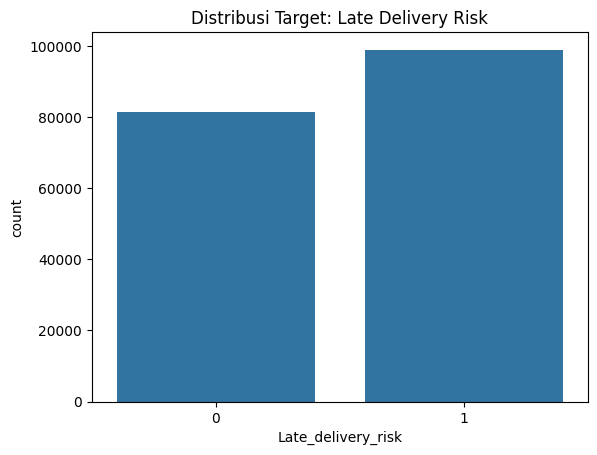

,proportion
Late_delivery_risk,
1,0.548291
0,0.451709


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['Late_delivery_risk'])
plt.title("Distribusi Target: Late Delivery Risk")
plt.show()

df['Late_delivery_risk'].value_counts(normalize=True)

##**Fitur Waktu**

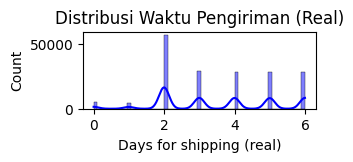

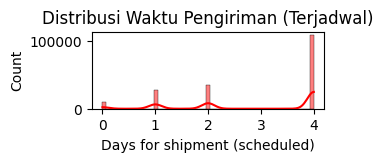

In [12]:
plt.figure(figsize=(3,1))
sns.histplot(df['Days for shipping (real)'], kde=True, color='blue')
plt.title("Distribusi Waktu Pengiriman (Real)")
plt.show()
plt.figure(figsize=(3,1))
sns.histplot(df['Days for shipment (scheduled)'], kde=True, color='red')
plt.title("Distribusi Waktu Pengiriman (Terjadwal)")
plt.show()

## **Fitur Logistik**

**Distribusi Durasi Pengiriman (Real) per Risiko**

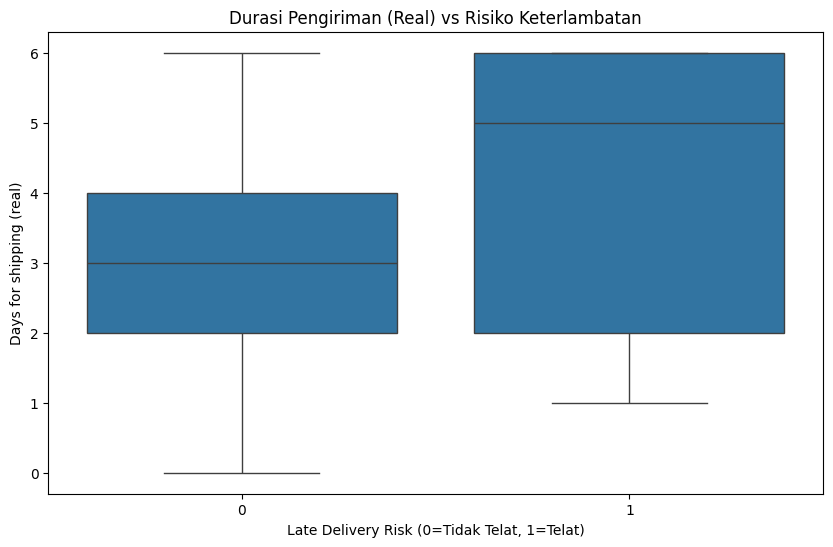

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df["Late_delivery_risk"], y=df["Days for shipping (real)"])
plt.title("Durasi Pengiriman (Real) vs Risiko Keterlambatan")
plt.xlabel("Late Delivery Risk (0=Tidak Telat, 1=Telat)")
plt.ylabel("Days for shipping (real)")
plt.show()

### **Selisih Waktu Real vs Scheduled**

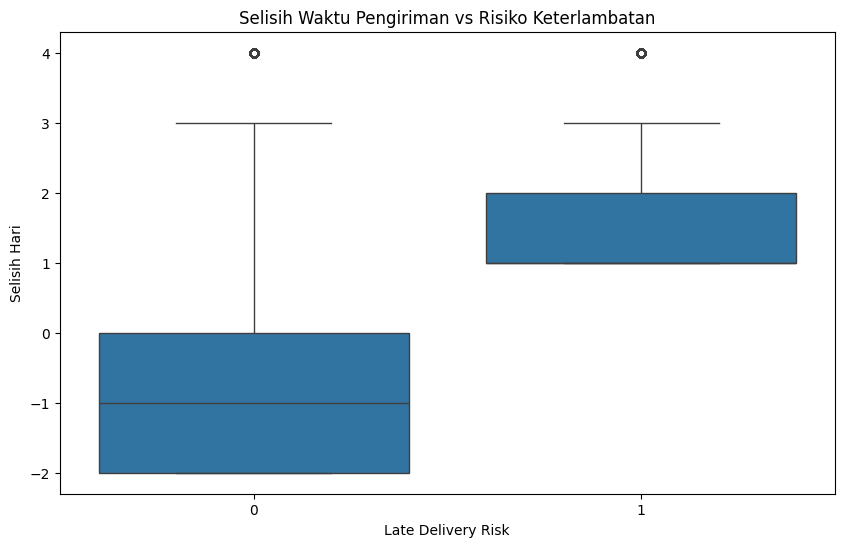

In [14]:
df["Time_Difference"] = df["Days for shipping (real)"] - df["Days for shipment (scheduled)"]

plt.figure(figsize=(10,6))
sns.boxplot(x=df["Late_delivery_risk"], y=df["Time_Difference"])
plt.title("Selisih Waktu Pengiriman vs Risiko Keterlambatan")
plt.xlabel("Late Delivery Risk")
plt.ylabel("Selisih Hari")
plt.show()

### **Analisis Per Region**

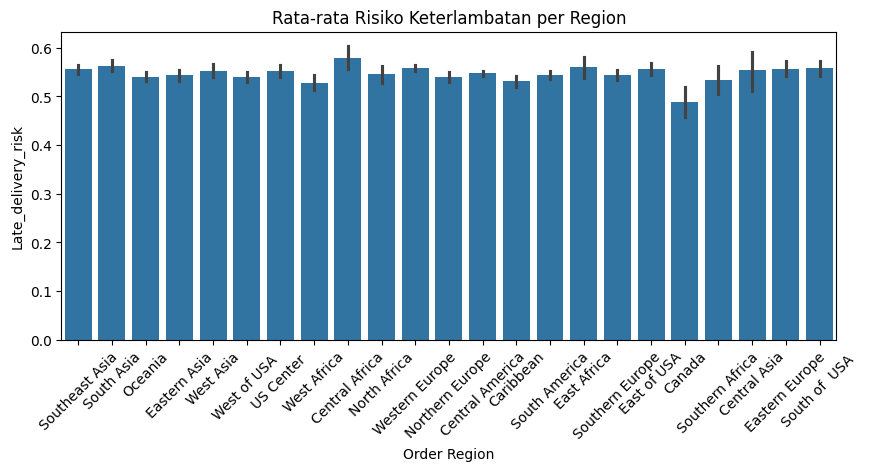

In [15]:
plt.figure(figsize=(10,4))
sns.barplot(x=df["Order Region"], y=df["Late_delivery_risk"])
plt.title("Rata-rata Risiko Keterlambatan per Region")
plt.xticks(rotation=45)
plt.show()

### **Analisis Per Route (Order City → Customer City)**

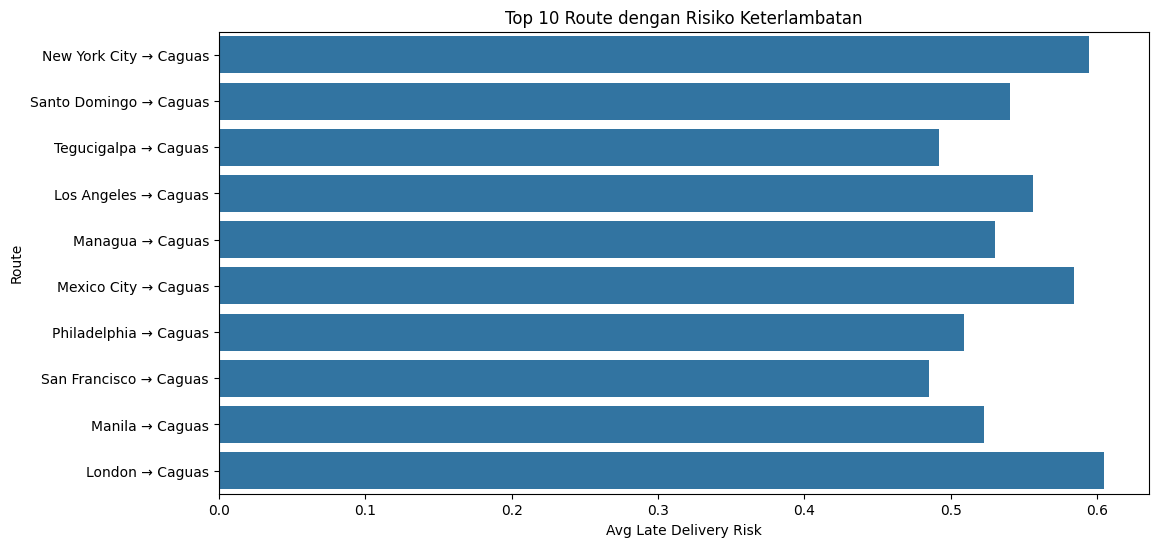

In [16]:
df["Route"] = df["Order City"].astype(str) + " → " + df["Customer City"].astype(str)

top_routes = df["Route"].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.barplot(
    y=top_routes,
    x=[df[df["Route"] == r]["Late_delivery_risk"].mean() for r in top_routes]
)
plt.title("Top 10 Route dengan Risiko Keterlambatan")
plt.xlabel("Avg Late Delivery Risk")
plt.ylabel("Route")
plt.show()

## **Fitur Pelanggan & Produk**

### **10 Kota Pelanggan Terbanyak**

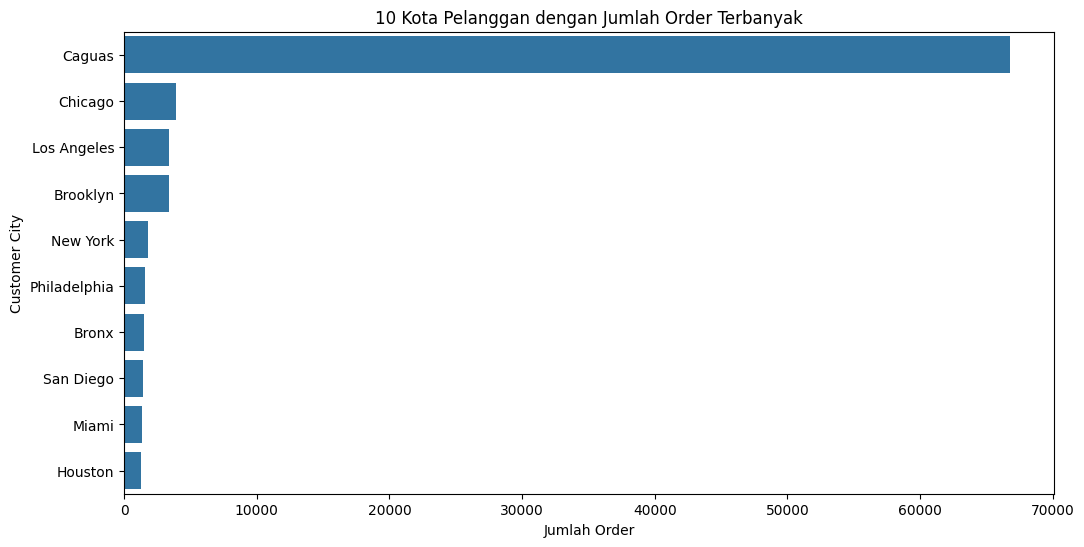

In [17]:
top_city = df["Customer City"].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_city.values, y=top_city.index)
plt.title("10 Kota Pelanggan dengan Jumlah Order Terbanyak")
plt.xlabel("Jumlah Order")
plt.ylabel("Customer City")
plt.show()

### **Durasi Pengiriman per Kategori Produk**


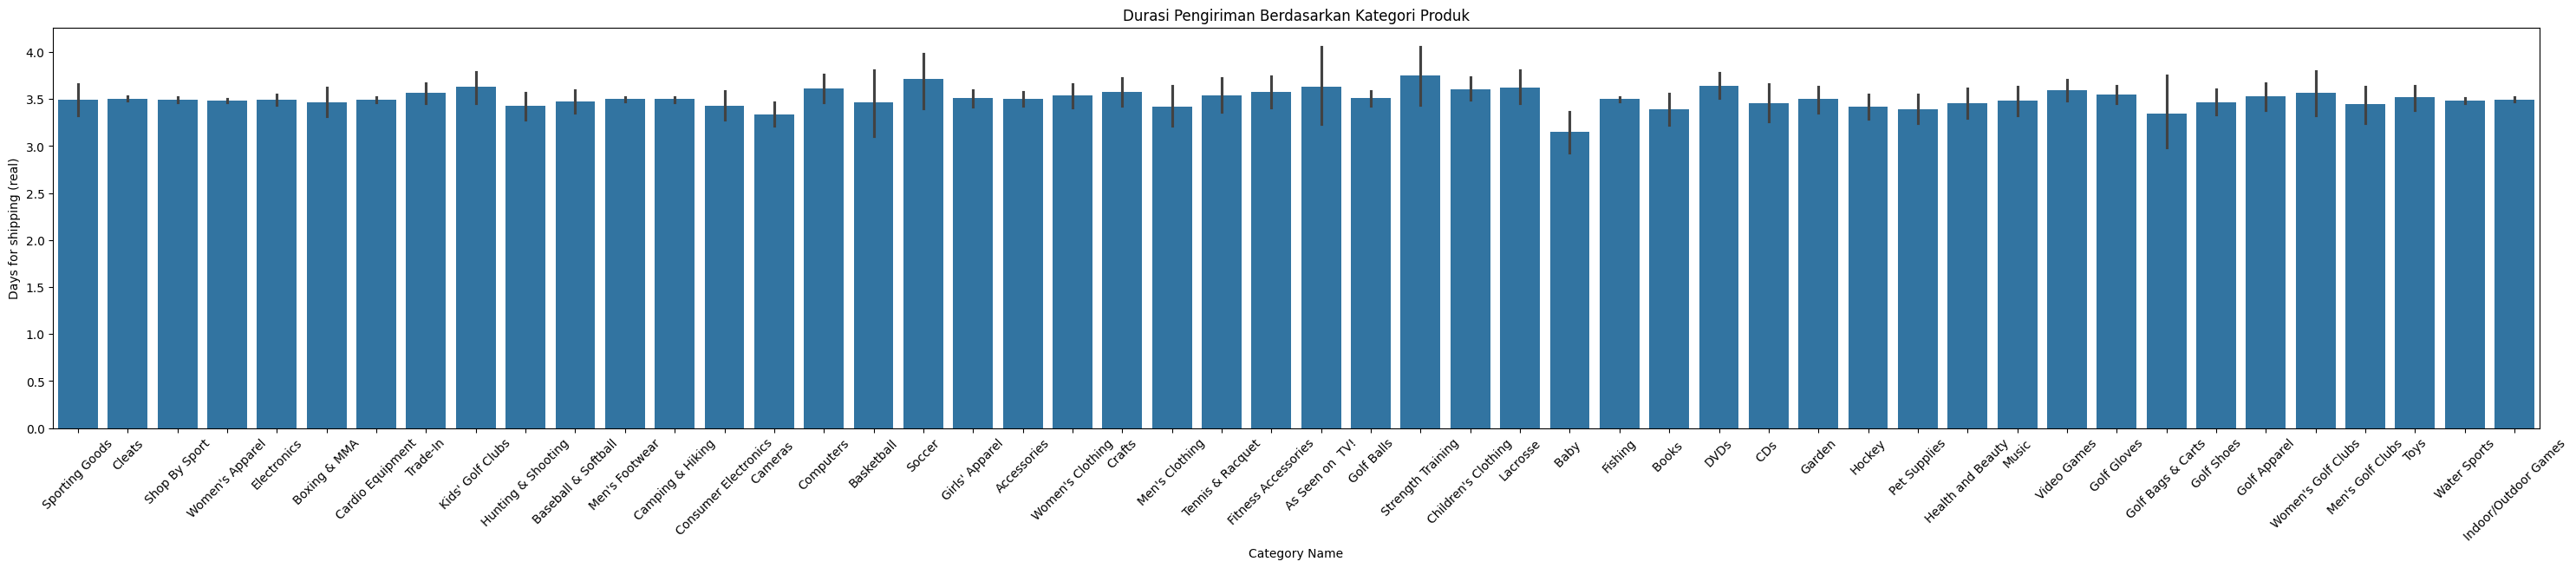

In [18]:
plt.figure(figsize=(37,6))
sns.barplot(x=df["Category Name"], y=df["Days for shipping (real)"])
plt.title("Durasi Pengiriman Berdasarkan Kategori Produk")
plt.xticks(rotation=45)
plt.show()

## **Korelasi & Feature**

### **Korelasi Fitur Numerik (Heatmap Besar)**

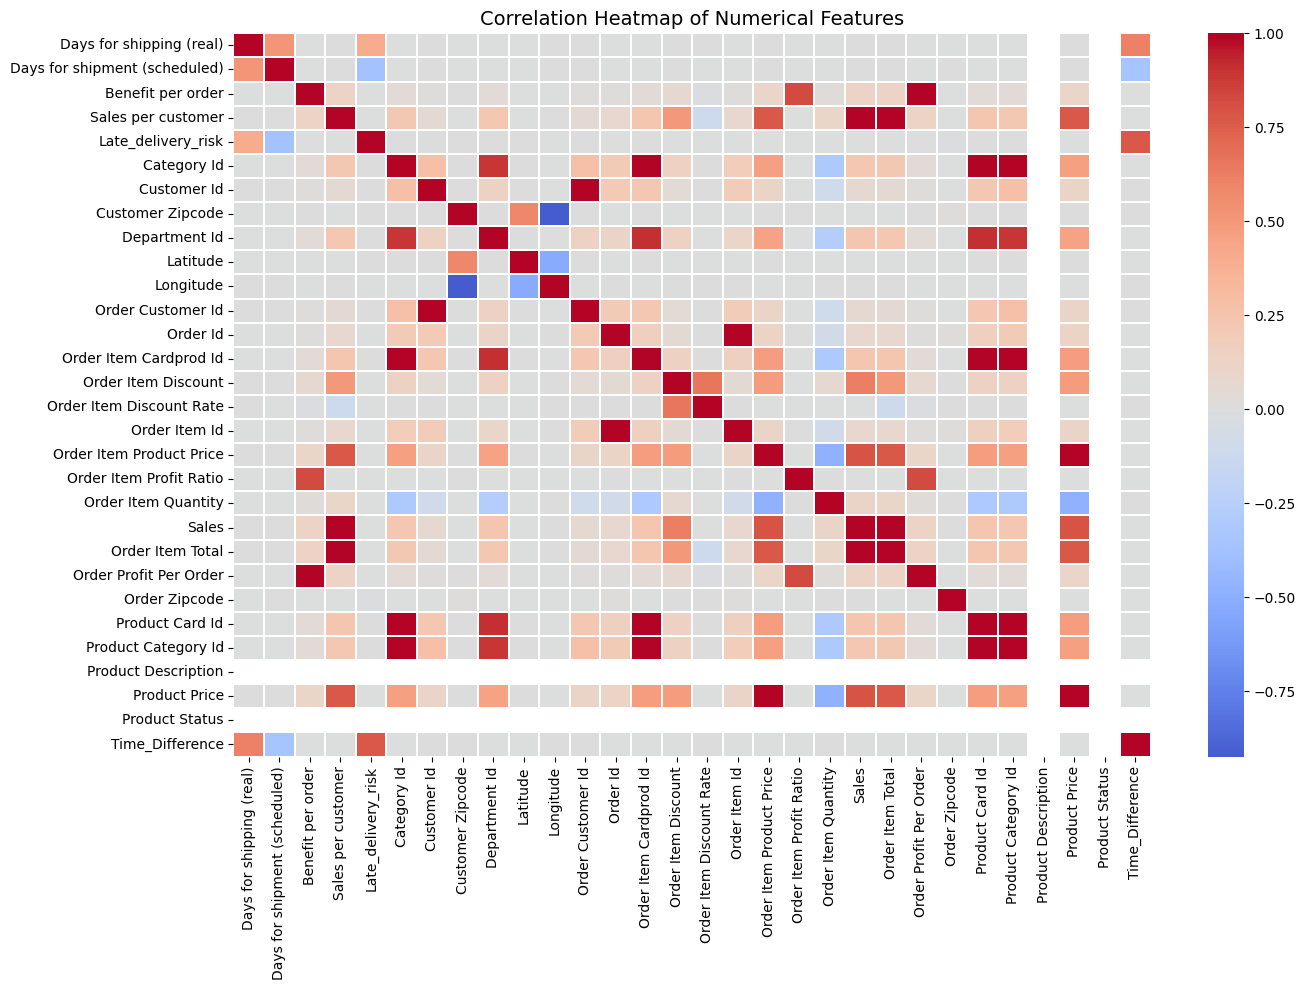

=== KORELASI FITUR NUMERIK TERHADAP TARGET ===


,Correlation with Late_delivery_risk
Time_Difference,0.777644
Days for shipping (real),0.401415
Days for shipment (scheduled),-0.369352
Order Zipcode,-0.014131
Order Item Total,-0.003791
Sales per customer,-0.003791
Order Profit Per Order,-0.003727
Benefit per order,-0.003727
Sales,-0.003564
Customer Zipcode,0.003148


In [19]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.3
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()
target_corr = (
    corr_matrix["Late_delivery_risk"]
    .drop("Late_delivery_risk")
    .sort_values(key=abs, ascending=False)
)

print("=== KORELASI FITUR NUMERIK TERHADAP TARGET ===")
display(target_corr.to_frame("Correlation with Late_delivery_risk"))

### **Korelasi Fitur Logistik**

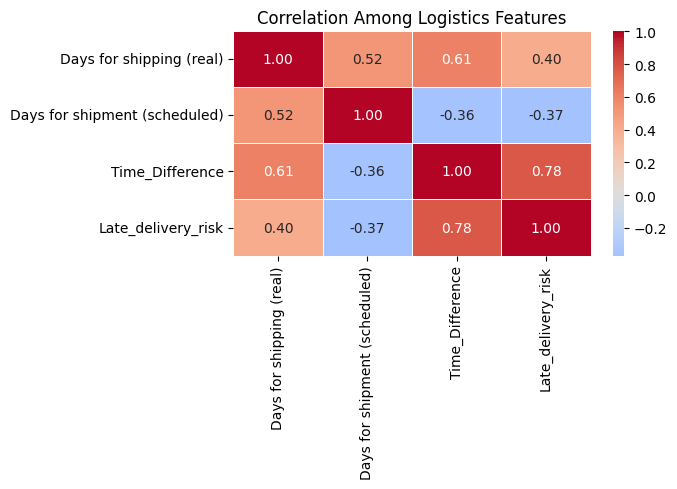

In [20]:
log_cols = [
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Time_Difference",
    "Late_delivery_risk"
]

log_corr = df[log_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    log_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Among Logistics Features")
plt.tight_layout()
plt.show()

### **Pair Plot**

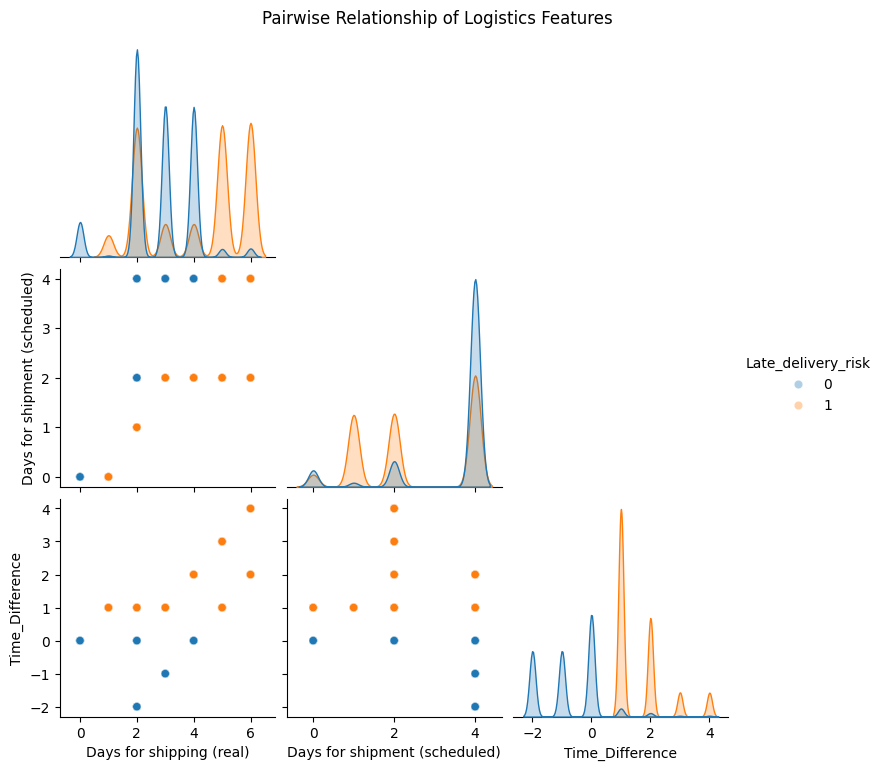

In [21]:
pair_cols = [
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Time_Difference",
    "Late_delivery_risk"
]

sns.pairplot(
    df[pair_cols],
    hue="Late_delivery_risk",
    corner=True,
    plot_kws={"alpha": 0.35}
)

plt.suptitle(
    "Pairwise Relationship of Logistics Features",
    y=1.02
)
plt.show()

# **DATA PREPROCESSING**

## **Cleaning**

### **Cek Missing**

In [22]:
df.isnull().sum()

,0
Type,0
Days for shipping (real),0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Delivery Status,0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer City,0


**Drop duplicates**

In [23]:
before_duplicates = len(df)

df = df.drop_duplicates().copy()

after_duplicates = len(df)

print("=== DUPLICATE HANDLING ===")
print(f"Baris sebelum : {before_duplicates:,}")
print(f"Duplikat dihapus : {before_duplicates - after_duplicates:,}")
print(f"Baris setelah : {after_duplicates:,}")

=== DUPLICATE HANDLING ===
Baris sebelum : 180,519
Duplikat dihapus : 0
Baris setelah : 180,519


### **Drop Sensitive Columns**

In [24]:
drop_sensitive = [
    'Customer Email', 'Customer Password',
    'Customer Fname', 'Customer Lname',
    'Customer Street', 'Customer State',
    'Customer Zipcode', 'Order Zipcode'
]

df = df.drop(columns=[c for c in drop_sensitive if c in df.columns], errors='ignore')

### **Drop NA Target**

In [25]:
df = df.dropna(subset=['Late_delivery_risk'])

### **Handling Missing Value (categorical → "unknown")**

In [26]:
print("=== MISSING VALUE HANDLING ===")

missing_before = df.isnull().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)

print("Missing value sebelum handling:")
display(missing_before.to_frame("Missing Values"))

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna("unknown")

missing_after = df.isnull().sum()
missing_after = missing_after[missing_after > 0]

print("\nMissing value setelah handling:")
if len(missing_after) == 0:
    print("Tidak ada missing value ✔")
else:
    display(missing_after.to_frame("Remaining Missing Values"))

print(f"\nShape dataset setelah cleaning: {df.shape}")

=== MISSING VALUE HANDLING ===
Missing value sebelum handling:


,Missing Values
Product Description,180519



Missing value setelah handling:


,Remaining Missing Values
Product Description,180519



Shape dataset setelah cleaning: (180519, 47)


## **Encoding dan Scalling**

### **Pilih Kolom & Bikin df_model**

In [27]:
selected_cols = [
    'Type',
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Benefit per order',
    'Sales per customer',
    'Order Item Quantity',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Profit Ratio',
    'Customer City',
    'Customer Country',
    'Order Region',
    'Order State',
    'Order Status',
    'Late_delivery_risk'
]

df_model = df[selected_cols].copy()

### **Definisikan X dan y**

In [28]:
y = df_model['Late_delivery_risk']
X = df_model.drop('Late_delivery_risk', axis=1)

## **Pisahkan Numerik & Kategorikal**

In [29]:
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numerik :", num_features)
print("Kategori:", cat_features)

Numerik : ['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Order Item Quantity', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio']
Kategori: ['Type', 'Customer City', 'Customer Country', 'Order Region', 'Order State', 'Order Status']


## **Encoding(OneHotEncode)**

In [30]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

categorical_transformer = Pipeline(steps=[
    ("imputer_cat", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

### **Scalling**

In [31]:
from sklearn.preprocessing import StandardScaler

numeric_transformer = Pipeline(steps=[
    ("imputer_num", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

### **Gabungan Encoding + Scalling (ColumnsTransformer)**

In [32]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)

## **Dataset Setelah Cleaning**

In [33]:
print(f"Jumlah baris  : {df.shape[0]:,}")
print(f"Jumlah kolom  : {df.shape[1]}")
print(f"Duplicate     : {df.duplicated().sum():,}")
print(f"Missing value : {df.isnull().sum().sum():,}")

print("\nStatus cleaning:")
if df.duplicated().sum() == 0 and df.isnull().sum().sum() == 0:
    print("Dataset siap digunakan untuk tahap berikutnya ✔")
else:
    print("Masih terdapat data yang perlu diperiksa.")

Jumlah baris  : 180,519
Jumlah kolom  : 47
Duplicate     : 0
Missing value : 180,519

Status cleaning:
Masih terdapat data yang perlu diperiksa.


# **FEATURE ENGINEERING**

### **Time Difference**

In [34]:
df["Time_Difference"] = (
    df["Days for shipping (real)"] - df["Days for shipment (scheduled)"]
)

### **Profit Margin**

In [35]:
df["Profit_Margin"] = (
    df["Order Item Profit Ratio"] * df["Order Item Product Price"]
)

### **Region Code**

In [36]:
df["Region_Code"] = df["Order Region"].astype('category').cat.codes

### **Route**

In [37]:
df["Route"] = df["Order City"].astype(str) + " → " + df["Customer City"].astype(str)

### **Order Hour**

In [38]:
df["OrderDate"] = pd.to_datetime(df["order date (DateOrders)"], errors="coerce")
df["Order_Hour"] = df["OrderDate"].dt.hour

### **Order Day of Week**

In [39]:
df["Order_DayOfWeek"] = df["OrderDate"].dt.dayofweek

# **PEMODELAN MACHINE LEARNING**

## **Train Test Split**

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### **Training Moden - Random Forest**

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42
    ))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer_num',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Days for shipping (real)',
                                                   'Days for shipment '
                                                   '(scheduled)',
                                                   'Benefit per order',
                                                   'Sales per customer',
                                                   'Order Item Quantity',
                                                   'Order Item Discount',
                                                   'Order Item Discount Rate',
                                                   'Order Item Product Price',
                                                   'Order Item Profit Ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer_cat',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Type', 'Customer City',
                                                   'Customer Country',
                                                   'Order Region',
                                                   'Order State',
                                                   'Order Status'])])),
                ('clf',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

## **Evaluasi Model**

In [42]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("=== HASIL EVALUASI MODEL RANDOM FOREST ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

=== HASIL EVALUASI MODEL RANDOM FOREST ===
Accuracy : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16308
           1       1.00      1.00      1.00     19796

    accuracy                           1.00     36104
   macro avg       1.00      1.00      1.00     36104
weighted avg       1.00      1.00      1.00     36104



## **Confusion Matrix**

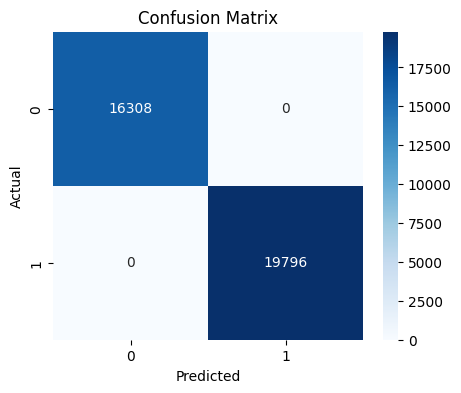

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **INTERPRETASI DAN INSIGHT**

## **Insight Keterlambatan**

### **INSIGHT 1 — Rata-rata Selisih Waktu (Time Difference)**

In [44]:
df.groupby("Late_delivery_risk")["Time_Difference"].mean()

,Time_Difference
Late_delivery_risk,
0,-0.711584
1,1.618184


### **INSIGHT 2 — Risiko Telat per Region**

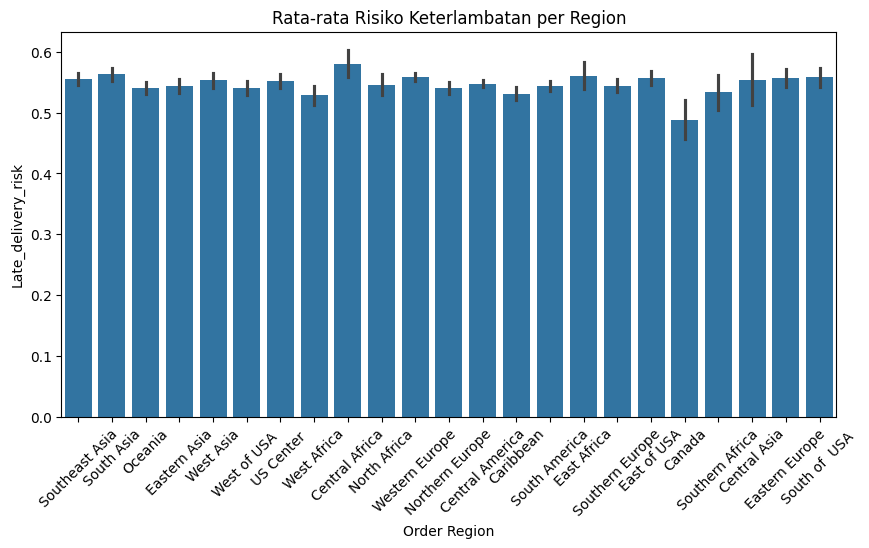

In [45]:
plt.figure(figsize=(10,5))
sns.barplot(x=df["Order Region"], y=df["Late_delivery_risk"])
plt.title("Rata-rata Risiko Keterlambatan per Region")
plt.xticks(rotation=45)
plt.show()

### **INSIGHT 3 — Risiko Telat per Shipping Mode**

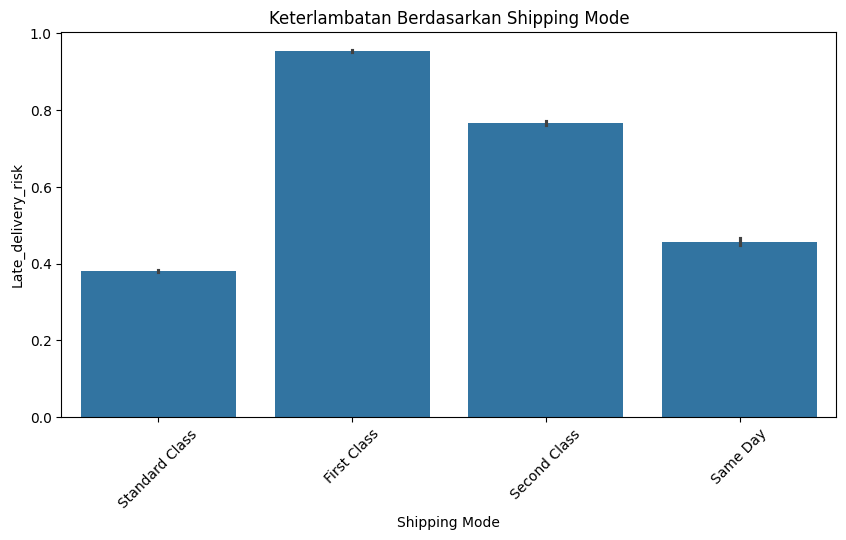

In [46]:
plt.figure(figsize=(10,5))
sns.barplot(x=df["Shipping Mode"], y=df["Late_delivery_risk"])
plt.title("Keterlambatan Berdasarkan Shipping Mode")
plt.xticks(rotation=45)
plt.show()

### **INSIGHT 4 — Produk yang paling sering telat (Kategori)**

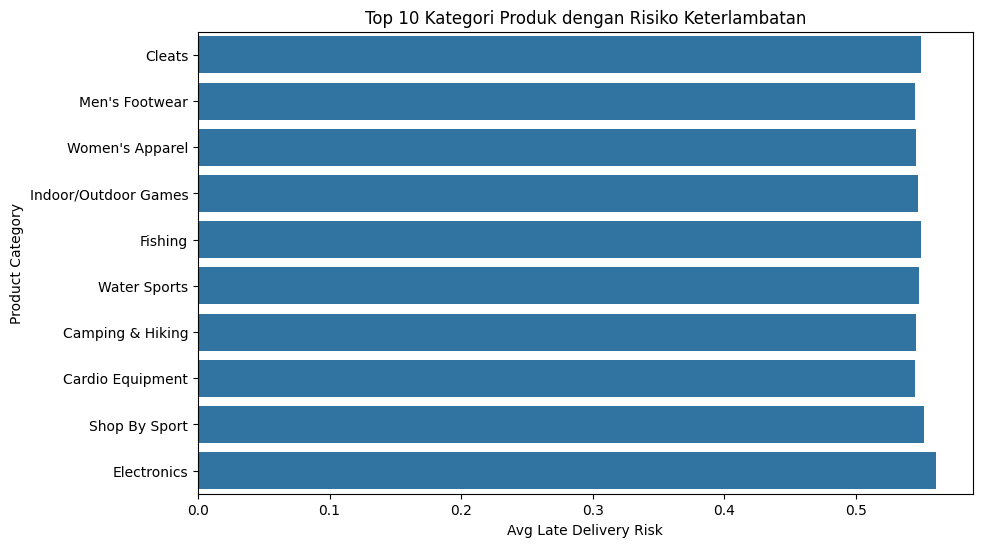

In [47]:
top_cat = df["Category Name"].value_counts().head(10).index

plt.figure(figsize=(10,6))
sns.barplot(
    y=top_cat,
    x=[df[df["Category Name"]==c]["Late_delivery_risk"].mean() for c in top_cat]
)
plt.title("Top 10 Kategori Produk dengan Risiko Keterlambatan")
plt.xlabel("Avg Late Delivery Risk")
plt.ylabel("Product Category")
plt.show()

### **INSIGHT 5 — Route (Jalur) dengan risiko tertinggi**

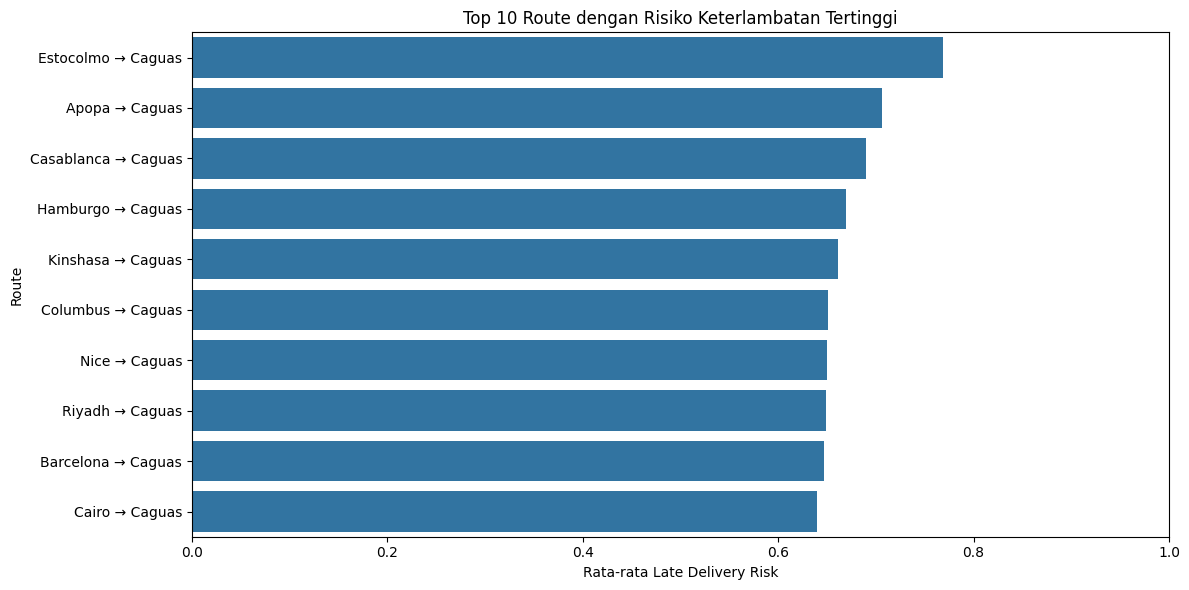

=== TOP 10 ROUTE ===


,Route,total_orders,late_risk
0,Estocolmo → Caguas,203,0.768473
1,Apopa → Caguas,143,0.706294
2,Casablanca → Caguas,142,0.690141
3,Hamburgo → Caguas,227,0.669604
4,Kinshasa → Caguas,183,0.661202
5,Columbus → Caguas,215,0.651163
6,Nice → Caguas,140,0.650000
7,Riyadh → Caguas,134,0.649254
8,Barcelona → Caguas,119,0.647059
9,Cairo → Caguas,211,0.639810


In [48]:
route_analysis = (
    df.groupby("Route")
      .agg(
          total_orders=("Late_delivery_risk", "size"),
          late_risk=("Late_delivery_risk", "mean")
      )
      .query("total_orders >= 100")
      .sort_values("late_risk", ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=route_analysis,
    x="late_risk",
    y="Route"
)

plt.title("Top 10 Route dengan Risiko Keterlambatan Tertinggi")
plt.xlabel("Rata-rata Late Delivery Risk")
plt.ylabel("Route")

plt.xlim(0, 1)
plt.tight_layout()
plt.show()

print("=== TOP 10 ROUTE ===")
display(route_analysis)

### **INSIGHT 6 — Jam Order & Risiko Telat**

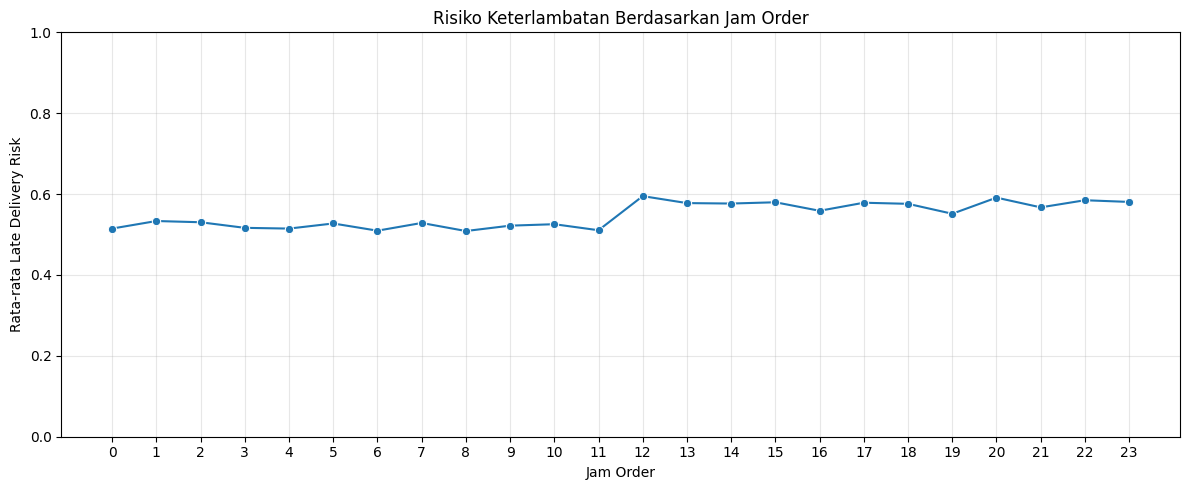

=== RISIKO KETERLAMBATAN PER JAM ===


,Order_Hour,total_orders,late_risk
0,0,7590,0.514756
1,1,7559,0.533404
2,2,7574,0.530367
3,3,7440,0.516532
4,4,7719,0.514704
5,5,7591,0.527335
6,6,7270,0.509491
7,7,7518,0.528598
8,8,7435,0.508675
9,9,7505,0.521919


In [49]:
hour_analysis = (
    df.groupby("Order_Hour")
      .agg(
          total_orders=("Late_delivery_risk", "size"),
          late_risk=("Late_delivery_risk", "mean")
      )
      .reset_index()
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hour_analysis,
    x="Order_Hour",
    y="late_risk",
    marker="o"
)

plt.title("Risiko Keterlambatan Berdasarkan Jam Order")
plt.xlabel("Jam Order")
plt.ylabel("Rata-rata Late Delivery Risk")
plt.xticks(range(0, 24))
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("=== RISIKO KETERLAMBATAN PER JAM ===")
display(hour_analysis)

### **INSIGHT 7 — Hari dalam Seminggu**

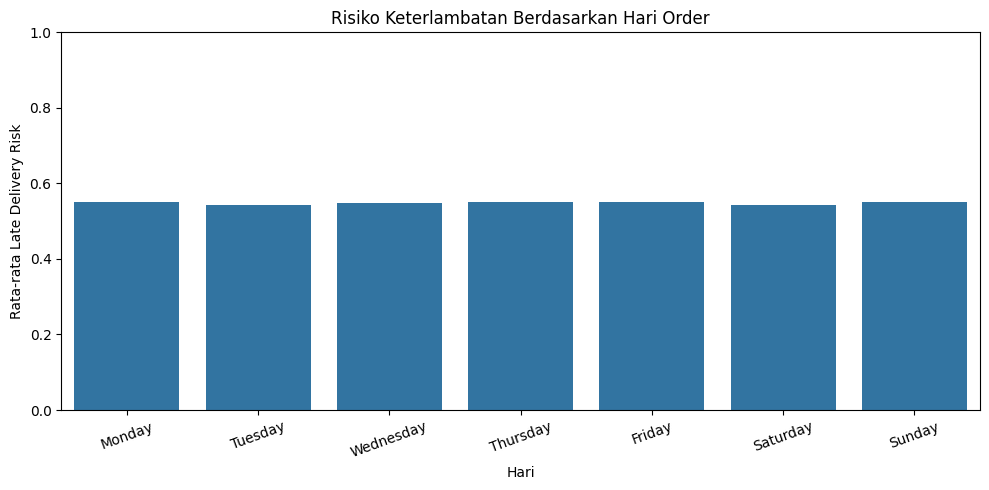

=== RISIKO KETERLAMBATAN PER HARI ===


,Day,total_orders,late_risk
0,Monday,25786,0.550531
1,Tuesday,25622,0.543010
2,Wednesday,25587,0.547583
3,Thursday,25752,0.550054
4,Friday,25925,0.551707
5,Saturday,25901,0.543956
6,Sunday,25946,0.551145


In [50]:
day_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_analysis = (
    df.groupby("Order_DayOfWeek")
      .agg(
          total_orders=("Late_delivery_risk", "size"),
          late_risk=("Late_delivery_risk", "mean")
      )
      .reset_index()
)

day_analysis["Day"] = day_analysis["Order_DayOfWeek"].map(
    dict(enumerate(day_names))
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=day_analysis,
    x="Day",
    y="late_risk"
)

plt.title("Risiko Keterlambatan Berdasarkan Hari Order")
plt.xlabel("Hari")
plt.ylabel("Rata-rata Late Delivery Risk")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print("=== RISIKO KETERLAMBATAN PER HARI ===")
display(
    day_analysis[
        ["Day", "total_orders", "late_risk"]
    ]
)

## **Feature Importance**

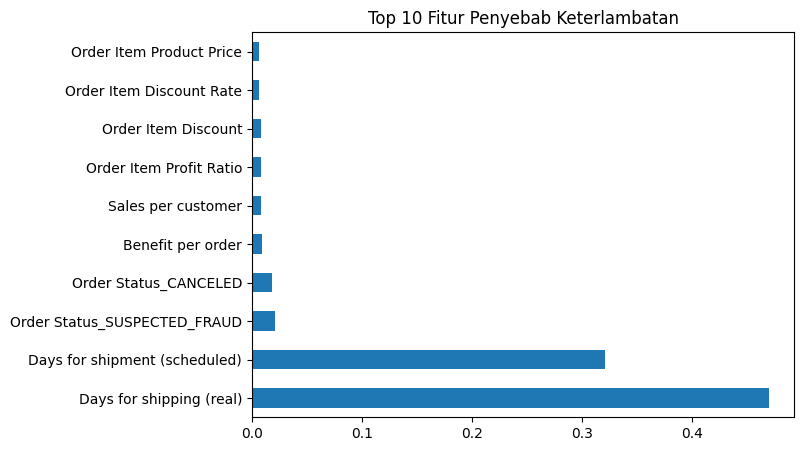

In [51]:
ohe = model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
ohe_features = list(ohe.get_feature_names_out(cat_features))
feature_names = num_features + ohe_features

importances = model.named_steps['clf'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)
feat_imp.plot(kind='barh', figsize=(7,5))
plt.title("Top 10 Fitur Penyebab Keterlambatan")
plt.show()